# Network Anomaly Detection for Lebanese SMBs
### LebNet Tech Fellows — Final Project (Option 2: AI for Lebanon)

This notebook trains an **Isolation Forest** anomaly detection model on the CIC-IDS2017
dataset to detect malicious network traffic, using only benign traffic during training
(unsupervised anomaly detection).

**Problem**: Lebanese SMBs cannot afford enterprise-grade security tools (CrowdStrike,
Darktrace, etc.). This project explores whether a lightweight, open-source anomaly
detection model can give small businesses *some* of that protection at near-zero cost.


## 1. Setup

In [1]:
import os
os.chdir(r"C:\youss\Personal\LebNet Summer 2026\Final Project\anomaly-detection-project\anomaly-detection")
print(os.getcwd())
print(os.listdir())

C:\youss\Personal\LebNet Summer 2026\Final Project\anomaly-detection-project\anomaly-detection
['.gitignore', 'dashboard', 'data', 'data_processed_feature_cols.json', 'models', 'notebooks', 'README.md', 'scripts']


In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)


## 2. Load the data

Get the files  and combine them into a dataset

In [3]:
DATA_FILES = [
    "data/raw/Monday-WorkingHours.pcap_ISCX.csv",
    "data/raw/Tuesday-WorkingHours.pcap_ISCX.csv",
    "data/raw/Wednesday-workingHours.pcap_ISCX.csv",
    "data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "data/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "data/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "data/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

dfs = []
for path in DATA_FILES:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]  # CIC CSVs often have leading spaces in headers
    print(f"{path}: {len(df):,} rows")
    print(df["Label"].value_counts())
    print()
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print(f"Total merged rows: {len(df):,}")
df.head()


data/raw/Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
BENIGN    529918
Name: Label, dtype: int64

data/raw/Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: Label, dtype: int64

data/raw/Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: Label, dtype: int64

data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: Label, dtype: int64

data/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
BENIGN          288566
Infiltration        36
Name: Label, dtype: int64

data/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
BENIGN    189067
Bot     

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,...,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,32046067,2,0,74,0,37,37,37.000000,0.000000,0,0,0.000000,0.000000,2.309176,0.062410,3.200000e+07,0.000000e+00,32000000,32000000,32000000,3.200000e+07,0.000000e+00,32000000,32000000,...,0.000000,64,0,0,0,0,0,0,2,74,0,0,65535,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,66073,4,4,176,428,44,44,44.000000,0.000000,107,107,107.000000,0.000000,9141.404204,121.078201,9.439000e+03,2.316343e+04,61865,4,65918,2.197267e+04,3.801361e+04,65867,4,...,107.000000,104,0,0,0,0,0,0,4,176,4,428,-1,-1,3,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,60025,1,1,56,112,56,56,56.000000,0.000000,112,112,112.000000,0.000000,2798.833819,33.319450,6.002500e+04,0.000000e+00,60025,60025,0,0.000000e+00,0.000000e+00,0,0,...,112.000000,32,0,0,0,0,0,0,1,56,1,112,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,47619,1,1,44,213,44,44,44.000000,0.000000,213,213,213.000000,0.000000,5397.005397,42.000042,4.761900e+04,0.000000e+00,47619,47619,0,0.000000e+00,0.000000e+00,0,0,...,213.000000,32,0,0,0,0,0,0,1,44,1,213,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,80,99329635,6,7,320,11595,302,0,53.333333,121.856746,4344,0,1656.428571,1760.597234,119.954131,0.130877,8.277470e+06,2.870000e+07,99300000,1,99300000,1.990000e+07,4.440000e+07,99300000,1,...,1656.428571,164,0,0,0,0,0,0,6,320,7,11595,0,235,3,20,13973.0,0.0,13973,13973,99300000.0,0.0,99300000,99300000,DoS Hulk


### Downsample benign traffic

All 8 files together are 2.8M rows, and the vast majority are BENIGN. Isolation Forest
doesn't need millions of near-duplicate "normal" flows to learn the pattern of normal
traffic, so downsampling the benign class keeps runtime fast without losing model quality.


In [4]:
MAX_BENIGN = 150_000  # cap the benign class; set to None to keep everything

if MAX_BENIGN is not None:
    benign_mask = df["Label"] == "BENIGN"
    n_benign = benign_mask.sum()
    if n_benign > MAX_BENIGN:
        benign_sampled = df[benign_mask].sample(n=MAX_BENIGN, random_state=42)
        df = pd.concat([benign_sampled, df[~benign_mask]], ignore_index=True)
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"Downsampled BENIGN from {n_benign:,} to {MAX_BENIGN:,} rows")
    else:
        print("Benign count already under MAX_BENIGN, no downsampling needed")

print(f"\nFinal dataset size: {len(df):,} rows")
print(df["Label"].value_counts())


Downsampled BENIGN from 2,273,097 to 150,000 rows

Final dataset size: 707,646 rows
DoS Hulk                      231073
PortScan                      158930
BENIGN                        150000
DDoS                          128027
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: Label, dtype: int64


## 3. Quick exploration

In [5]:
print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())
print("\nLabel distribution (%):")
print((df["Label"].value_counts(normalize=True) * 100).round(2))


Shape: (707646, 79)

Label distribution:
DoS Hulk                      231073
PortScan                      158930
BENIGN                        150000
DDoS                          128027
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: Label, dtype: int64

Label distribution (%):
DoS Hulk                      32.65
PortScan                      22.46
BENIGN                        21.20
DDoS                          18.09
DoS GoldenEye                  1.45
FTP-Patator                    1.12
SSH-Patator                    0.83
DoS slowloris                  0.82
DoS Slowhttptest               0.78
Bot                          

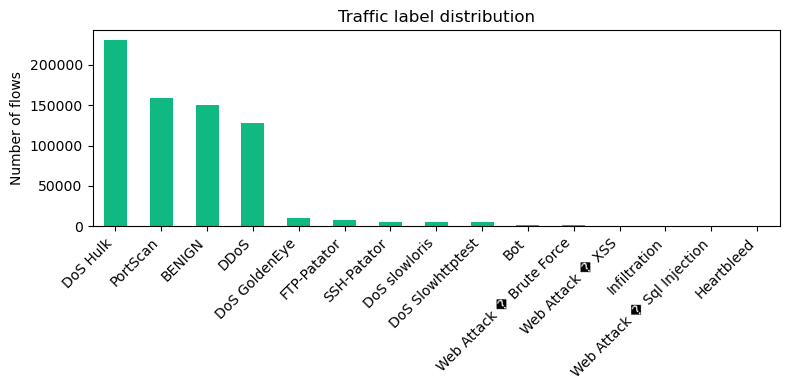

In [6]:
df["Label"].value_counts().plot(kind="bar", figsize=(8,4), color="#10b981")
plt.title("Traffic label distribution")
plt.ylabel("Number of flows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Clean the data

- Drop identifier columns (IPs, flow ID, timestamp, ports) — these would let the model
  "cheat" by memorizing addresses instead of learning traffic *patterns*.
- Replace inf/NaN values — CICFlowMeter produces these for some divide-by-zero cases
  (e.g. `Flow Bytes/s` when duration is 0).

In [7]:
IDENTIFIER_COLS = ["Flow ID", "Source IP", "Destination IP", "Timestamp", "Source Port", "Destination Port"]
LABEL_COL = "Label"

identifier_cols_present = [c for c in IDENTIFIER_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c != LABEL_COL and c not in identifier_cols_present]

print(f"{len(feature_cols)} feature columns, {len(identifier_cols_present)} identifier columns excluded")

df_clean = df.replace([np.inf, -np.inf], np.nan)
before = len(df_clean)
df_clean = df_clean.dropna()
print(f"Dropped {before - len(df_clean)} rows with inf/NaN values ({len(df_clean)} rows remain)")

#In short: this cell decides what the model is allowed to see (behavioral features only, no identifiers) 
#and removes rows with broken/missing values so the math in later steps doesn't break or get corrupted by infinities.

77 feature columns, 1 identifier columns excluded
Dropped 1191 rows with inf/NaN values (706455 rows remain)


## 5. Train/test split

**Key idea for unsupervised anomaly detection**: the model is trained ONLY on benign
traffic. It never sees attack examples during training — it just learns what "normal"
looks like, then flags anything that deviates. Attack rows are held out purely for
*evaluation*, never used to fit the model.

**Balancing the test set**: real networks are mostly normal traffic — attacks are the
rare exception, not the majority. If we evaluate against every attack row from all 8
files unchanged, the test set ends up **90%+ attacks**, which doesn't reflect a real
deployment and makes standard accuracy hard to interpret. So each attack *type* is capped
at a max count below — common attack types (DoS Hulk, PortScan, etc.) are downsampled,
while rare types (Heartbleed, Infiltration) are kept in full since they're already small.
This gives a test set with a more realistic, still evaluable anomaly rate.

In [8]:
benign = df_clean[df_clean[LABEL_COL] == "BENIGN"] 
#Filters df_clean down to only rows where the label is "BENIGN" 
#this creates a new table containing just the normal traffic.


attacks_full = df_clean[df_clean[LABEL_COL] != "BENIGN"]
#The opposite filter — every row that is not benign, 
#every attack row (DDoS, PortScan, DoS Hulk, etc.), all combined into one table.

print(f"Benign rows: {len(benign):,}")
print(f"Attack rows before capping: {len(attacks_full):,}")

MAX_PER_ATTACK_TYPE = 500  # cap each attack type; rare types below this are kept whole

attacks = pd.concat(
    [g.sample(n=min(len(g), MAX_PER_ATTACK_TYPE), random_state=42)
     for _, g in attacks_full.groupby(LABEL_COL)],
    ignore_index=True,
)
print(f"Attack rows after capping (max {MAX_PER_ATTACK_TYPE} per type): {len(attacks):,}")
print(attacks[LABEL_COL].value_counts())

benign_train, benign_test = train_test_split(benign, test_size=0.3, random_state=42)

# Test set = held-out benign + capped attack rows -> more realistic traffic mix
test_df = pd.concat([benign_test, attacks], ignore_index=True).sample(frac=1, random_state=42)

print(f"\nTrain set (benign only): {len(benign_train):,}")
anomaly_rate = (test_df[LABEL_COL] != "BENIGN").mean()
print(f"Test set (mixed): {len(test_df):,}  |  anomaly rate: {anomaly_rate:.2%}")


Benign rows: 149,899
Attack rows before capping: 556,556
Attack rows after capping (max 500 per type): 5,568
Bot                           500
DDoS                          500
DoS GoldenEye                 500
DoS Hulk                      500
DoS Slowhttptest              500
DoS slowloris                 500
FTP-Patator                   500
PortScan                      500
SSH-Patator                   500
Web Attack � Brute Force      500
Web Attack � XSS              500
Infiltration                   36
Web Attack � Sql Injection     21
Heartbleed                     11
Name: Label, dtype: int64

Train set (benign only): 104,929
Test set (mixed): 50,538  |  anomaly rate: 11.02%


## 6. Scale features

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(benign_train[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_test = (test_df[LABEL_COL] != "BENIGN").astype(int).values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (104929, 77)
X_test shape: (50538, 77)


## 7. Train the Isolation Forest

Isolation Forest is an ensemble of random decision trees. The core idea: anomalies are
"few and different," so random splits isolate them into their own leaf faster than normal
points. Anomaly score = how quickly a point gets isolated — short path length = more anomalous.

In [10]:
model = IsolationForest(
    n_estimators=150,
    contamination=0.05,   
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train)
print("Model trained.")


Model trained.


## 8. Evaluate on the held-out test set

In [11]:
raw_scores = model.score_samples(X_test)
anomaly_scores = -raw_scores   # flip sign so higher = more anomalous (more intuitive)
predictions = model.predict(X_test)   # 1 = normal, -1 = anomaly
y_pred = (predictions == -1).astype(int)

print("=== Classification report (0=normal, 1=attack) ===")
print(classification_report(y_test, y_pred, digits=3))

auc = roc_auc_score(y_test, anomaly_scores)
print(f"ROC-AUC: {auc:.4f}")


=== Classification report (0=normal, 1=attack) ===
              precision    recall  f1-score   support

           0      0.906     0.949     0.927     44970
           1      0.338     0.209     0.258      5568

    accuracy                          0.868     50538
   macro avg      0.622     0.579     0.593     50538
weighted avg      0.844     0.868     0.854     50538

ROC-AUC: 0.7409


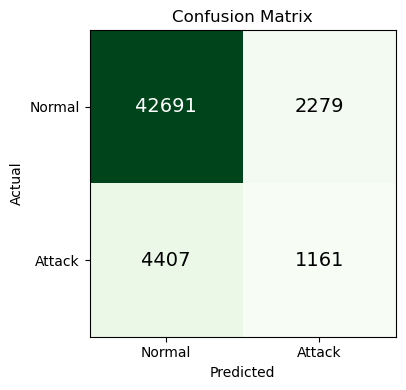

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks([0,1]); ax.set_xticklabels(["Normal", "Attack"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Normal", "Attack"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=14,
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


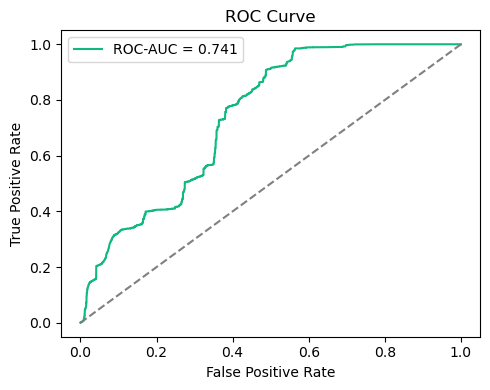

In [13]:
fpr, tpr, _ = roc_curve(y_test, anomaly_scores)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color="#10b981", label=f"ROC-AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Find the best decision threshold\n\nUseful for setting severity cutoffs in the dashboard.

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_scores)
f1_scores = np.divide(
    2 * precisions * recalls, precisions + recalls,
    out=np.zeros_like(precisions), where=(precisions + recalls) != 0
)
best_idx = int(np.argmax(f1_scores[:-1])) if len(thresholds) else 0
best_threshold = float(thresholds[best_idx]) if len(thresholds) else 0.0
print(f"Best-F1 threshold: {best_threshold:.4f}  (F1={f1_scores[best_idx]:.3f})")


Best-F1 threshold: 0.3536  (F1=0.317)


## 10. Save the model, scaler, and metrics

In [15]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/isolation_forest.joblib")
joblib.dump(scaler, "models/scaler.joblib")

metrics = {
    "roc_auc": auc,
    "confusion_matrix": cm.tolist(),
    "best_f1_threshold": best_threshold,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "test_anomaly_rate": float(y_test.mean()),
}
with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open("data_processed_feature_cols.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print("Saved model, scaler, and metrics to models/")


Saved model, scaler, and metrics to models/


## 11. Export scored flows for the Node.js dashboard

This produces `dashboard/public/flows.json`, which the Express server reads directly —
no live Python inference needed for the demo.

In [16]:
def severity_label(score, threshold):
    if score < threshold * 0.5:
        return "low"
    elif score < threshold:
        return "medium"
    elif score < threshold * 1.5:
        return "high"
    return "critical"

LIMIT = 1500  # cap rows for a snappy demo UI (raised since we now have more attack variety)
n = min(LIMIT, len(test_df))
test_df_reset = test_df.reset_index(drop=True)

rows = []
for i in range(n):
    rows.append({
        "id": i,
        "sourceIp": str(test_df_reset.iloc[i].get("Source IP", "N/A")),
        "destIp": str(test_df_reset.iloc[i].get("Destination IP", "N/A")),
        "flowDuration": float(test_df_reset.iloc[i].get("Flow Duration", 0)),
        "packets": int(test_df_reset.iloc[i].get("Total Fwd Packets", 0)),
        "trueLabel": str(test_df_reset.iloc[i].get("Label", "UNKNOWN")),
        "anomalyScore": round(float(anomaly_scores[i]), 4),
        "predictedAnomaly": bool(y_pred[i]),
        "severity": severity_label(float(anomaly_scores[i]), best_threshold),
    })

output = {
    "generatedAt": pd.Timestamp.now().isoformat(),
    "threshold": best_threshold,
    "metrics": {
        "rocAuc": auc,
        "testAnomalyRate": float(y_test.mean()),
        "confusionMatrix": cm.tolist(),
    },
    "flows": rows,
}

os.makedirs("dashboard/public", exist_ok=True)
with open("dashboard/public/flows.json", "w") as f:
    json.dump(output, f, indent=2)

print(f"Exported {n} scored flows to dashboard/public/flows.json")
print(f"Flagged as anomalous: {sum(r['predictedAnomaly'] for r in rows)}/{n}")


Exported 1500 scored flows to dashboard/public/flows.json
Flagged as anomalous: 102/1500


## 12. Next step

Launch the dashboard to see the results live:

```bash
cd dashboard
npm install
node server.js
```

Then open **http://localhost:3000** in  browser.
